In [10]:
#Data Set of a restaurant orders on zomato is taken

In [49]:
#Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [86]:
#Load data
data = pd.read_csv("order_history.csv")   

print("Dataset Loaded Successfully!\n")
data

Dataset Loaded Successfully!



,Restaurant ID,Restaurant name,Subzone,City,Order ID,Order Placed At,Items in order,Discount construct,Bill subtotal,Packaging charges,Restaurant discount (Promo),Total,Order Ready Marked
0,20320607,Swaad,Sector 4,Delhi NCR,6168884918,"11:38 PM, September 10 2024","1 x Grilled Chicken Jamaican Tender, 1 x Grill...",40% off upto Rs.80,715.0,31.75,80.0,666.75,Correctly
1,20320607,Swaad,Sector 4,Delhi NCR,6170707559,"11:34 PM, September 10 2024","1 x Peri Peri Fries, 1 x Fried Chicken Angara ...",Flat Rs.175 off,1179.0,50.20,175.0,1054.20,Correctly
2,20320607,Swaad,Sector 4,Delhi NCR,6169375019,"03:52 PM, September 10 2024",1 x Bone in Peri Peri Grilled Chicken,40% off upto Rs.80,310.0,11.50,80.0,241.50,Correctly
3,20320607,Swaad,Sector 4,Delhi NCR,6151677434,"03:45 PM, September 10 2024","1 x Fried Chicken Ghostbuster Tender, 1 x Anga...",40% off upto Rs.80,620.0,27.00,80.0,567.00,Correctly
4,20320607,Swaad,Sector 4,Delhi NCR,6167540897,"03:04 PM, September 10 2024","1 x Peri Peri Krispers, 1 x Fried Chicken Anga...",40% off upto Rs.80,584.0,25.20,80.0,529.20,Correctly
...,...,...,...,...,...,...,...,...,...,...,...,...,...
21316,21467440,The Chicken Junction,Chittaranjan Park,Delhi NCR,6568490993,"03:26 AM, January 30 2025",1 x Fried Chicken Desi Peri Peri Bites (Bone),50% off upto Rs.100,510.0,21.00,90.0,441.00,Correctly
21317,21467440,The Chicken Junction,Chittaranjan Park,Delhi NCR,6564842673,"02:44 AM, January 29 2025",1 x Fried Chicken 65 Masala Boneless Bites,Flat 15% off,560.0,24.22,75.6,508.62,Missed
21318,21523055,Masala Junction,Sector 4,Delhi NCR,6553527557,"10:05 PM, January 24 2025",1 x Korean Fried Chicken Slider,NaN,430.0,21.50,0.0,451.50,Incorrectly
21319,21523055,Masala Junction,Sector 4,Delhi NCR,6541170157,"02:27 PM, January 21 2025",1 x Ooh Saucy Fries,NaN,339.0,16.95,0.0,355.95,Correctly


In [76]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21321 entries, 0 to 21320
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Restaurant ID                21321 non-null  int64  
 1   Restaurant name              21321 non-null  object 
 2   Subzone                      21321 non-null  object 
 3   City                         21321 non-null  object 
 4   Order ID                     21321 non-null  int64  
 5   Order Placed At              21321 non-null  object 
 6   Unnamed: 6                   0 non-null      float64
 7   Unnamed: 7                   0 non-null      float64
 8   Items in order               21321 non-null  object 
 9   Discount construct           15823 non-null  object 
 10  Bill subtotal                21321 non-null  float64
 11  Packaging charges            21321 non-null  float64
 12  Restaurant discount (Promo)  21321 non-null  float64
 13  Total           

In [77]:
data.isnull().sum()

Restaurant ID                      0
Restaurant name                    0
Subzone                            0
City                               0
Order ID                           0
Order Placed At                    0
Unnamed: 6                     21321
Unnamed: 7                     21321
Items in order                     0
Discount construct              5498
Bill subtotal                      0
Packaging charges                  0
Restaurant discount (Promo)        0
Total                              0
Order Ready Marked                 0
dtype: int64

In [78]:
data.describe()

,Restaurant ID,Order ID,Unnamed: 6,Unnamed: 7,Bill subtotal,Packaging charges,Restaurant discount (Promo),Total
count,2.132100e+04,2.132100e+04,0.0,0.0,21321.000000,21321.000000,21321.000000,21321.000000
mean,2.074413e+07,6.354622e+09,NaN,NaN,750.076838,32.564592,65.091816,682.616113
std,2.447193e+05,1.230263e+08,NaN,NaN,498.759428,22.235898,85.401604,465.313977
min,2.032061e+07,6.086767e+09,NaN,NaN,50.000000,0.000000,0.000000,52.500000
25%,2.063570e+07,6.250751e+09,NaN,NaN,459.000000,18.450000,0.000000,387.450000
50%,2.065987e+07,6.357715e+09,NaN,NaN,629.000000,28.450000,80.000000,597.450000
75%,2.088265e+07,6.456827e+09,NaN,NaN,899.000000,39.950000,100.000000,837.900000
max,2.152306e+07,6.573392e+09,NaN,NaN,16080.000000,603.000000,4020.000000,12663.000000


In [79]:
# pip install plotly
import plotly.express as px

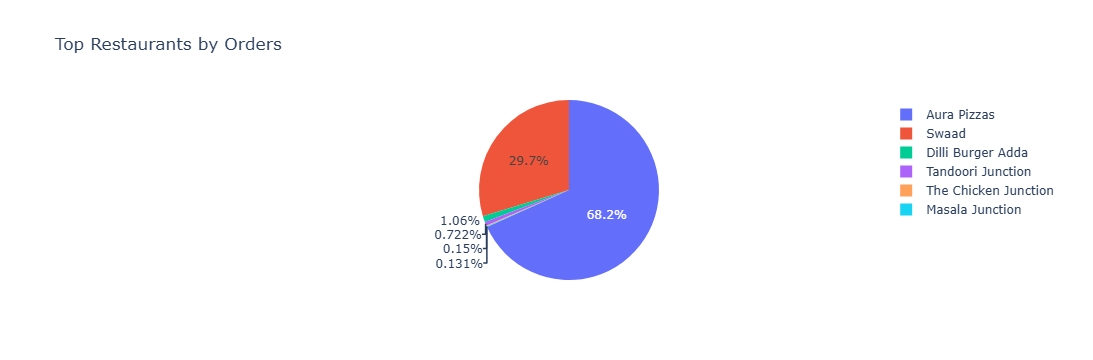

In [80]:
pie = data["Restaurant name"].value_counts().head(10)

pie_df = pie.reset_index()
pie_df.columns = ["Restaurant", "Orders"]

fig = px.pie(pie_df, values="Orders", names="Restaurant",
             title="Top Restaurants by Orders")

fig.show()

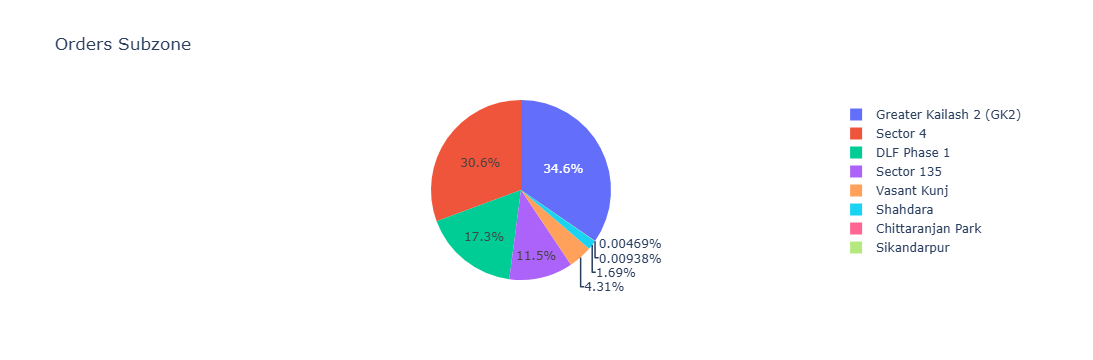

In [81]:
pie = data["Subzone"].value_counts()

pie_df = pie.reset_index()
pie_df.columns = ["Subzone", "Orders"]

fig = px.pie(pie_df,
             values="Orders",
             names="Subzone",
             title="Orders Subzone")

fig.show()

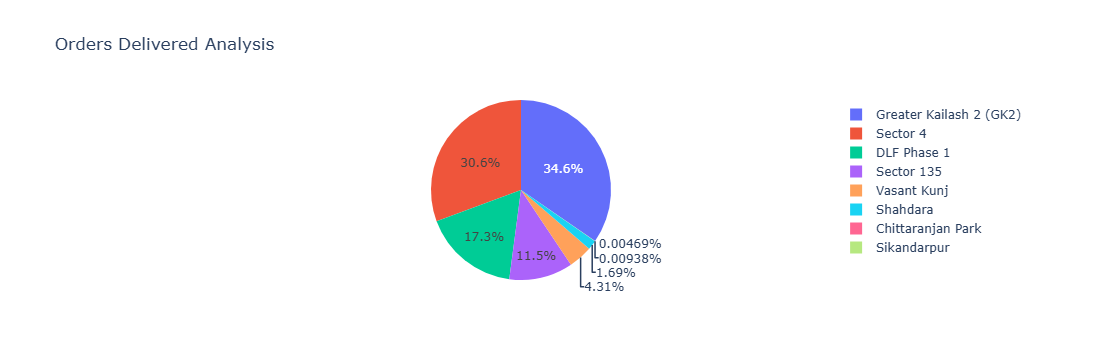

In [82]:
pie_df.columns = ["Status", "Orders"]

fig = px.pie(pie_df,
             values="Orders",
             names="Status",
             title="Orders Delivered Analysis")

fig.show()

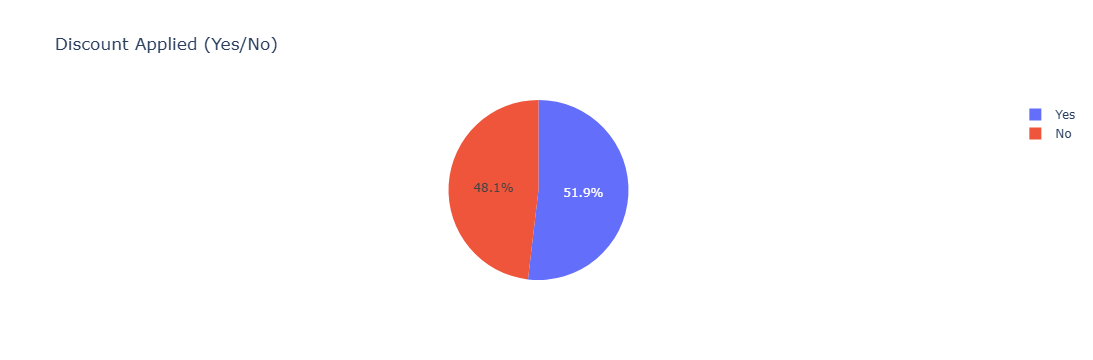

In [87]:
# Create Yes/No column
data["Discount_Applied"] = data["Restaurant discount (Promo)"].apply(
    lambda x: "Yes" if x != 0 else "No"
)

# Count Yes/No
pie = data["Discount_Applied"].value_counts()

pie_df = pie.reset_index()
pie_df.columns = ["Discount Applied", "Orders"]

fig = px.pie(pie_df,
             values="Orders",
             names="Discount Applied",
             title="Discount Applied (Yes/No)")

fig.show()

In [91]:
# Encode categorical columns
le = LabelEncoder()
data["Restaurant name"] = le.fit_transform(data["Restaurant name"])
data["Subzone"] = le.fit_transform(data["Subzone"])
data["Order Ready Marked"] = le.fit_transform(data["Order Ready Marked"])

# Features
X = np.array(data[["Restaurant name", "Subzone", "Total", "Order Ready Marked"]])

# Target (choose correctly)
y = np.array(data["Total"])   # or another valid column

In [92]:
X

array([[3.0000e+00, 4.0000e+00, 6.6675e+02, 0.0000e+00],
       [3.0000e+00, 4.0000e+00, 1.0542e+03, 0.0000e+00],
       [3.0000e+00, 4.0000e+00, 2.4150e+02, 0.0000e+00],
       ...,
       [2.0000e+00, 4.0000e+00, 4.5150e+02, 1.0000e+00],
       [2.0000e+00, 4.0000e+00, 3.5595e+02, 0.0000e+00],
       [2.0000e+00, 4.0000e+00, 3.0450e+02, 0.0000e+00]], shape=(21321, 4))

In [94]:
y

array([ 666.75, 1054.2 ,  241.5 , ...,  451.5 ,  355.95,  304.5 ],
      shape=(21321,))

In [15]:
#Create features
orders_per_day["date"] = pd.to_datetime(orders_per_day["date"])

orders_per_day["day"] = orders_per_day["date"].dt.day
orders_per_day["month"] = orders_per_day["date"].dt.month
orders_per_day["year"] = orders_per_day["date"].dt.year

X = orders_per_day[["day", "month", "year"]]
y = orders_per_day["num_orders"]

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [95]:
len(X_train)

122

In [20]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


In [19]:
#predict, evaluate
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("MODEL PERFORMANCE")
print("MAE:", round(mae, 2))
print("MSE:", round(mse, 2))

MODEL PERFORMANCE
MAE: 38.16
MSE: 2356.8


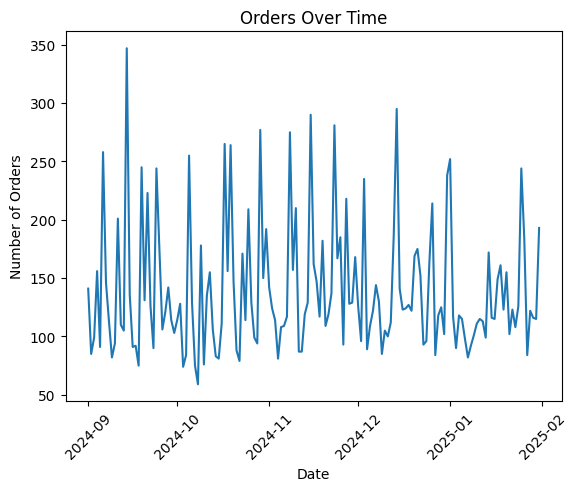

In [24]:
#Graph 1 : Orders over time
plt.figure()
plt.plot(orders_per_day["date"], orders_per_day["num_orders"])
plt.title("Orders Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

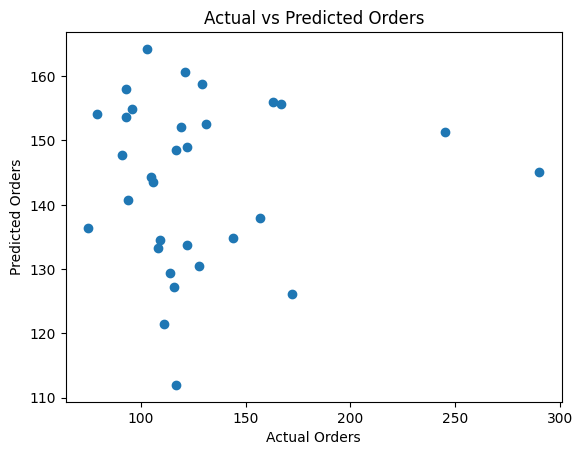

In [25]:
#Graph 2: Actual vs Predicted
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Orders")
plt.ylabel("Predicted Orders")
plt.title("Actual vs Predicted Orders")
plt.show()

In [27]:
#Future prediction
future_dates = pd.date_range(start=orders_per_day["date"].max(), periods=7)

future_df = pd.DataFrame({
    "day": future_dates.day,
    "month": future_dates.month,
    "year": future_dates.year
})

future_pred = model.predict(future_df)

print("\n FUTURE ORDER PREDICTIONS:\n")

for i in range(len(future_dates)):
    print(f"{future_dates[i].date()} → {int(future_pred[i])} orders")


 FUTURE ORDER PREDICTIONS:

2025-01-31 → 146 orders
2025-02-01 → 110 orders
2025-02-02 → 111 orders
2025-02-03 → 112 orders
2025-02-04 → 113 orders
2025-02-05 → 114 orders
2025-02-06 → 115 orders
